In [39]:
#3 IMPORTS + BASIC SETUP

import os
import re
import json
import math
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

from openai import OpenAI
import google.generativeai as genai
import anthropic

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Imports loaded successfully")
print("Working directory:", os.getcwd())

Imports loaded successfully
Working directory: c:\Project_On_LLM\notebooks


In [40]:
# PROJECT PATHS + DATASET SETUP

# project root
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
CORRUPT_DIR = PROJECT_ROOT / "data" / "corrupted"
BASELINE_DIR = PROJECT_ROOT / "data" / "cleaned_baseline"
LLM_DIR = PROJECT_ROOT / "data" / "cleaned_llm"

CORRUPT_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
LLM_DIR.mkdir(parents=True, exist_ok=True)

# datasets
FILES = {
    "blood": "blood.csv",
    "boston_airbnb": "boston_airbnb.csv",
    "credit_risk": "credit_risk.csv",
    "medical_appointments": "medical_appointments.csv",
    "telco_customer_churn": "telco_customer_churn.csv",
    "student_exam": "student_exam_performance_dataset.csv",
    "dengue": "Dengue_diseases_dataset_modified.csv",
    "breast_cancer": "breast_cancer_40_features_1M.csv",
}

# targets
TARGETS = {
    "blood": "class",
    "boston_airbnb": "price",
    "credit_risk": "person_income",
    "medical_appointments": "age",
    "telco_customer_churn": "churn",
    "student_exam": "assignment_completion_rate",       
    "dengue": "dengue_label",
    "breast_cancer": "diagnosis",
}

print("RAW_DIR:", RAW_DIR)
print("Datasets found:", os.listdir(RAW_DIR))

RAW_DIR: C:\Project_On_LLM\data\raw
Datasets found: ['blood.csv', 'boston_airbnb.csv', 'breast_cancer_40_features_1M.csv', 'credit_risk.csv', 'Dengue_diseases_dataset_modified.csv', 'medical_appointments.csv', 'student_exam_performance_dataset.csv', 'telco_customer_churn.csv']


In [41]:
# COLUMN NORMALIZATION HELPERS

def normalize_colname(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s+", "_", s)
    return s


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [normalize_colname(c) for c in df.columns]
    return df


def coerce_numeric_series(s: pd.Series) -> pd.Series:

    if pd.api.types.is_numeric_dtype(s):
        return s

    x = s.astype(str).str.strip()

    x = x.replace({
        "": np.nan,
        "nan": np.nan,
        "None": np.nan
    })

    x = x.str.replace(r"[\$,]", "", regex=True)
    x = x.str.replace("%", "", regex=False)

    out = pd.to_numeric(x, errors="coerce")

    return out


def ensure_target_numeric_or_binary(df: pd.DataFrame, target: str) -> pd.DataFrame:

    df = df.copy()

    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found")

    y = df[target]

    y_num = coerce_numeric_series(y)

    if y_num.notna().mean() >= 0.8:
        df[target] = y_num
        df = df[df[target].notna()].copy()
        return df

    uniq = y.dropna().astype(str).unique()

    if len(uniq) == 2:
        mapping = {uniq[0]: 0, uniq[1]: 1}
        df[target] = y.astype(str).map(mapping)
        df = df[df[target].notna()].copy()
        return df

    raise ValueError(
        f"Target '{target}' is not numeric and not binary."
    )


print("Column normalization helpers loaded.")

Column normalization helpers loaded.


In [42]:
# LOAD RAW DATASETS SAFELY

raw_data = {}
dataset_summary = []
load_errors = []

for name, fname in FILES.items():
    path = RAW_DIR / fname

    try:
        df = pd.read_csv(path)
        df = normalize_columns(df)

        target = normalize_colname(TARGETS[name])
        df = ensure_target_numeric_or_binary(df, target)

        raw_data[name] = df

        dataset_summary.append({
            "dataset": name,
            "rows": df.shape[0],
            "cols": df.shape[1],
            "target": target,
            "missing_target": int(df[target].isna().sum()),
            "status": "loaded"
        })

        print(f"Loaded -> {name}")

    except Exception as e:
        load_errors.append({
            "dataset": name,
            "file": fname,
            "error": str(e)
        })
        print(f"Error -> {name} | {e}")

summary_df = pd.DataFrame(dataset_summary).sort_values("dataset").reset_index(drop=True)
errors_df = pd.DataFrame(load_errors)

print("\nLoaded datasets summary:")
display(summary_df)

if len(errors_df) > 0:
    print("\nDatasets with loading errors:")
    display(errors_df)
else:
    print("\nAll datasets loaded successfully.")

Loaded -> blood
Loaded -> boston_airbnb
Loaded -> credit_risk
Loaded -> medical_appointments
Loaded -> telco_customer_churn
Loaded -> student_exam
Loaded -> dengue
Loaded -> breast_cancer

Loaded datasets summary:


,dataset,rows,cols,target,missing_target,status
0,blood,748,5,class,0,loaded
1,boston_airbnb,3585,95,price,0,loaded
2,breast_cancer,500000,41,diagnosis,0,loaded
3,credit_risk,32581,12,person_income,0,loaded
4,dengue,989,9,dengue_label,0,loaded
5,medical_appointments,110527,14,age,0,loaded
6,student_exam,10000,23,assignment_completion_rate,0,loaded
7,telco_customer_churn,7043,21,churn,0,loaded



All datasets loaded successfully.


In [43]:
# COLUMN SELECTION HELPERS

def pick_columns(df: pd.DataFrame, protected_cols=None):

    protected_cols = set(protected_cols or [])

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    text_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    skip_pattern = re.compile(
        r"(id$|_id$|customerid|rowid|index|ssn|email|phone|zip|zipcode)",
        re.I
    )

    num_cols = [
        c for c in num_cols
        if (not skip_pattern.search(str(c))) and (c not in protected_cols)
    ]

    text_cols = [
        c for c in text_cols
        if (not skip_pattern.search(str(c))) and (c not in protected_cols)
    ]

    return num_cols, text_cols


print("Column selection helper ready.")

Column selection helper ready.


In [44]:
# DATA CORRUPTION HELPERS

SEED = 42
rng = np.random.default_rng(SEED)

MISSING_RATE = 0.10
DUPLICATE_RATE = 0.05
OUTLIER_RATE = 0.03
TEXT_NOISE_RATE = 0.05


def inject_missing(df, cols, rate):

    if not cols or rate <= 0:
        return df

    df2 = df.copy()

    n_rows = len(df2)
    n_cols = len(cols)

    k = max(1, int(n_rows * n_cols * rate))

    row_idx = rng.integers(0, n_rows, size=k)
    col_idx = rng.integers(0, n_cols, size=k)

    for r, ci in zip(row_idx, col_idx):
        col = cols[ci]
        df2.iat[r, df2.columns.get_loc(col)] = np.nan

    return df2


def inject_duplicates(df, rate):

    if rate <= 0 or len(df) < 2:
        return df

    k = max(1, int(len(df) * rate))

    dup_rows = df.sample(n=k, random_state=SEED)

    return pd.concat([df, dup_rows], ignore_index=True)


def inject_outliers(df, num_cols, rate):

    if not num_cols or rate <= 0:
        return df

    df2 = df.copy()

    n_rows = len(df2)
    k = max(1, int(n_rows * rate))

    for col in num_cols:

        rows = rng.choice(n_rows, size=min(k, n_rows), replace=False)

        s = df2[col].dropna()

        if s.empty:
            continue

        scale = s.std()

        if scale == 0 or pd.isna(scale):
            scale = (s.max() - s.min())

        if scale == 0 or pd.isna(scale):
            scale = 10

        for r in rows:

            if pd.isna(df2.at[r, col]):
                continue

            v = df2.at[r, col]

            df2.at[r, col] = v + rng.normal(0, 5 * scale)

    return df2


def typo(val):

    if not isinstance(val, str) or len(val) == 0:
        return val

    choice = rng.integers(0, 3)

    if choice == 0:
        return val.upper()

    elif choice == 1 and len(val) >= 3:
        i = rng.integers(0, len(val))
        return val[:i] + val[i+1:]

    else:
        if len(val) < 2:
            return val

        i = rng.integers(0, len(val)-1)
        return val[:i] + val[i+1] + val[i] + val[i+2:]


def inject_text_noise(df, text_cols, rate):

    if not text_cols or rate <= 0:
        return df

    df2 = df.copy()

    n_rows = len(df2)
    n_cols = len(text_cols)

    k = max(1, int(n_rows * n_cols * rate))

    row_idx = rng.integers(0, n_rows, size=k)
    col_idx = rng.integers(0, n_cols, size=k)

    for r, ci in zip(row_idx, col_idx):

        col = text_cols[ci]

        val = df2.at[r, col]

        if pd.isna(val):
            continue

        df2.at[r, col] = typo(str(val))

    return df2


print("Corruption helpers ready.")

Corruption helpers ready.


In [45]:
# CREATE + SAVE CORRUPTED DATA

MAX_ROWS_FOR_CORRUPTION = 100000

def corrupt_dataset(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    dfc = df.copy()

    # protect target from corruption
    num_cols, text_cols = pick_columns(dfc, protected_cols=[target_col])

    dfc = inject_missing(dfc, cols=(num_cols + text_cols), rate=MISSING_RATE)
    dfc = inject_text_noise(dfc, text_cols=text_cols, rate=TEXT_NOISE_RATE)
    dfc = inject_outliers(dfc, num_cols=num_cols, rate=OUTLIER_RATE)
    dfc = inject_duplicates(dfc, rate=DUPLICATE_RATE)

    return dfc


corrupt_info = []
corrupt_errors = []
corrupted_data = {}

for name, df in raw_data.items():
    target = normalize_colname(TARGETS[name])

    try:
        df_work = df.copy()

        if len(df_work) > MAX_ROWS_FOR_CORRUPTION:
            df_work = df_work.sample(n=MAX_ROWS_FOR_CORRUPTION, random_state=SEED).reset_index(drop=True)

        df_corrupt = corrupt_dataset(df_work, target_col=target)
        df_corrupt = normalize_columns(df_corrupt)
        df_corrupt = ensure_target_numeric_or_binary(df_corrupt, target)

        out_path = CORRUPT_DIR / f"{name}_corrupted.csv"
        df_corrupt.to_csv(out_path, index=False)

        corrupted_data[name] = df_corrupt

        corrupt_info.append({
            "dataset": name,
            "target": target,
            "input_rows_used": df_work.shape[0],
            "input_cols_used": df_work.shape[1],
            "corrupt_rows": df_corrupt.shape[0],
            "corrupt_cols": df_corrupt.shape[1],
            "saved_to": str(out_path),
            "status": "success"
        })

        print(f"Done -> {name}")

    except Exception as e:
        corrupt_errors.append({
            "dataset": name,
            "target": target,
            "error": str(e)
        })
        print(f"Error -> {name} | {e}")

corrupt_df = pd.DataFrame(corrupt_info).sort_values("dataset").reset_index(drop=True)
corrupt_errors_df = pd.DataFrame(corrupt_errors)

print("\nCorrupted datasets summary:")
display(corrupt_df)

if len(corrupt_errors_df) > 0:
    print("\nDatasets with corruption errors:")
    display(corrupt_errors_df)
else:
    print("\nAll corrupted datasets created and saved successfully.")

Done -> blood


C:\Users\panit\AppData\Local\Temp\ipykernel_18880\3669115677.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


Done -> boston_airbnb


C:\Users\panit\AppData\Local\Temp\ipykernel_18880\3669115677.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


Done -> credit_risk


...

Done -> student_exam
Done -> dengue


C:\Users\panit\AppData\Local\Temp\ipykernel_18880\3669115677.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


Done -> breast_cancer

Corrupted datasets summary:


,dataset,target,input_rows_used,input_cols_used,corrupt_rows,corrupt_cols,saved_to,status
0,blood,class,748,5,785,5,C:\Project_On_LLM\data\corrupted\blood_corrupt...,success
1,boston_airbnb,price,3585,95,3764,95,C:\Project_On_LLM\data\corrupted\boston_airbnb...,success
2,breast_cancer,diagnosis,100000,41,105000,41,C:\Project_On_LLM\data\corrupted\breast_cancer...,success
3,credit_risk,person_income,32581,12,34210,12,C:\Project_On_LLM\data\corrupted\credit_risk_c...,success
4,dengue,dengue_label,989,9,1038,9,C:\Project_On_LLM\data\corrupted\dengue_corrup...,success
5,medical_appointments,age,100000,14,105000,14,C:\Project_On_LLM\data\corrupted\medical_appoi...,success
6,student_exam,assignment_completion_rate,10000,23,10500,23,C:\Project_On_LLM\data\corrupted\student_exam_...,success
7,telco_customer_churn,churn,7043,21,7395,21,C:\Project_On_LLM\data\corrupted\telco_custome...,success



All corrupted datasets created and saved successfully.


In [46]:
# BASELINE MODEL PIPELINE

def build_pipeline(num_cols, text_cols):

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median"))
    ])

    text_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    pre = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("text", text_pipe, text_cols)
    ])

    model = Pipeline([
        ("prep", pre),
        ("reg", Ridge(alpha=1.0))
    ])

    return model


print("Baseline pipeline ready.")

Baseline pipeline ready.


In [83]:
# BASELINE CLEANING FUNCTIONS

def safe_str_series(s: pd.Series) -> pd.Series:
    out = s.astype(str)
    out = out.replace({
        "nan": np.nan,
        "None": np.nan,
        "none": np.nan,
        "": np.nan
    })
    return out


def duplicate_removal(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates().copy()


def text_standardization(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    text_cols = df.select_dtypes(include=["object", "category", "string"]).columns

    for c in text_cols:
        df[c] = safe_str_series(df[c]).str.strip().str.lower()

    return df


def type_coercion(df: pd.DataFrame, threshold: float = 0.7) -> pd.DataFrame:
    df = df.copy()

    for c in df.columns:
        if df[c].dtype == "object":
            converted = pd.to_numeric(df[c], errors="coerce")
            if converted.notna().mean() >= threshold:
                df[c] = converted

    return df


def impute_simple(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            med = df[c].median()
            if pd.isna(med):
                med = 0
            df[c] = df[c].fillna(med)
        else:
            mode_vals = df[c].mode(dropna=True)
            fill_val = mode_vals.iloc[0] if len(mode_vals) > 0 else "unknown"
            df[c] = df[c].fillna(fill_val)

    return df


def impute_distribution(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for c in df.columns:
        s = df[c]
        miss = s.isna()

        if not miss.any():
            continue

        if pd.api.types.is_numeric_dtype(s):
            pool = s.dropna().to_numpy()
            df.loc[miss, c] = rng.choice(pool, size=int(miss.sum()), replace=True) if pool.size else 0
        else:
            vc = s.dropna().astype(str).value_counts(normalize=True)
            if vc.empty:
                df.loc[miss, c] = "unknown"
            else:
                values = vc.index.to_list()
                probs = vc.values
                df.loc[miss, c] = rng.choice(values, size=int(miss.sum()), replace=True, p=probs)

    return df


def outliers_iqr_cap(df: pd.DataFrame, factor: float = 1.5) -> pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns

    for c in num_cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1

        if pd.isna(iqr) or iqr == 0:
            continue

        lo = q1 - factor * iqr
        hi = q3 + factor * iqr
        df[c] = df[c].clip(lo, hi)

    return df


def outliers_zscore_cap(df: pd.DataFrame, z_thresh: float = 3.0) -> pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns

    for c in num_cols:
        s = pd.to_numeric(df[c], errors="coerce")
        mu = s.mean()
        sigma = s.std()

        if pd.isna(sigma) or sigma == 0:
            continue

        z = (s - mu) / sigma
        df.loc[z > z_thresh, c] = mu + z_thresh * sigma
        df.loc[z < -z_thresh, c] = mu - z_thresh * sigma

    return df


def baseline_simple_impute(df: pd.DataFrame) -> pd.DataFrame:
    df = duplicate_removal(df)
    df = text_standardization(df)
    df = type_coercion(df)
    df = impute_simple(df)
    return df


def baseline_dist_impute(df: pd.DataFrame) -> pd.DataFrame:
    df = duplicate_removal(df)
    df = text_standardization(df)
    df = type_coercion(df)
    df = impute_distribution(df)
    return df


def baseline_iqr_cap(df: pd.DataFrame) -> pd.DataFrame:
    df = baseline_simple_impute(df)
    df = outliers_iqr_cap(df)
    return df


def baseline_zscore_cap(df: pd.DataFrame) -> pd.DataFrame:
    df = baseline_simple_impute(df)
    df = outliers_zscore_cap(df)
    return df

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

def baseline_logistic_detect_then_repair(df: pd.DataFrame) -> pd.DataFrame:
    df0 = duplicate_removal(df)
    df0 = text_standardization(df0)
    df0 = type_coercion(df0)

    if df0.empty:
        return df0.copy()

    df_fix = df0.copy()

    num_cols = df_fix.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df_fix.select_dtypes(exclude=[np.number]).columns.tolist()

    if len(num_cols) == 0 and len(cat_cols) == 0:
        return df_fix.copy()

    # Ensure numeric columns are float
    if num_cols:
        df_fix[num_cols] = df_fix[num_cols].apply(pd.to_numeric, errors="coerce").astype(float)

    # -------------------------------------------------
    # Step 1: create anomaly labels for logistic detect
    # -------------------------------------------------
    # A row is marked anomalous if:
    #   - it has any missing values, OR
    #   - any numeric feature has |z| > 3
    row_has_missing = df_fix.isna().any(axis=1)

    if num_cols:
        z_parts = []
        for c in num_cols:
            s = df_fix[c]
            mu = s.mean()
            sigma = s.std()

            if pd.isna(sigma) or sigma == 0:
                continue

            z_parts.append(((s - mu) / sigma).abs())

        if z_parts:
            max_abs_z = pd.concat(z_parts, axis=1).max(axis=1)
            row_has_extreme = max_abs_z > 3
        else:
            row_has_extreme = pd.Series(False, index=df_fix.index)
    else:
        row_has_extreme = pd.Series(False, index=df_fix.index)

    y = (row_has_missing | row_has_extreme).astype(int)

    # Need both normal and anomalous rows
    if y.nunique() < 2:
        return impute_simple(df_fix)

    # --------------------------------
    # Step 2: build feature matrix X
    # --------------------------------
    X = df_fix.copy()

    # Encode categorical columns
    for c in cat_cols:
        X[c] = X[c].fillna("missing").astype(str)
        le = LabelEncoder()
        X[c] = le.fit_transform(X[c])

    # Fill numeric missing values
    for c in num_cols:
        med = X[c].median()
        if pd.isna(med):
            med = 0.0
        X[c] = X[c].fillna(med)

    # Scale numeric columns
    if num_cols:
        scaler = StandardScaler()
        X[num_cols] = scaler.fit_transform(X[num_cols])

    # --------------------------------
    # Step 3: logistic detection
    # --------------------------------
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X, y)

    probs = clf.predict_proba(X)[:, 1]
    flagged = probs > 0.5

    # --------------------------------
    # Step 4: repair flagged rows
    # --------------------------------
    for c in num_cols:
        clean_med = df_fix.loc[~flagged, c].median()
        if pd.isna(clean_med):
            clean_med = df_fix[c].median()
        if pd.isna(clean_med):
            clean_med = 0.0
        df_fix.loc[flagged, c] = df_fix.loc[flagged, c].fillna(clean_med)
        df_fix.loc[flagged & df_fix[c].notna(), c] = float(clean_med)

    for c in cat_cols:
        mode_vals = df_fix.loc[~flagged, c].mode(dropna=True)
        fill_val = mode_vals.iloc[0] if len(mode_vals) > 0 else "unknown"
        df_fix.loc[flagged, c] = df_fix.loc[flagged, c].fillna(fill_val)
        df_fix.loc[flagged & df_fix[c].notna(), c] = fill_val

    # Final cleanup
    df_fix = impute_simple(df_fix)
    return df_fix

BASELINES = {
    "simple_impute": baseline_simple_impute,
    "dist_impute": baseline_dist_impute,
    "iqr_cap": baseline_iqr_cap,
    "zscore_cap": baseline_zscore_cap,
    "logistic_detect": baseline_logistic_detect_then_repair,
}

print("Baseline cleaning functions loaded.")

Baseline cleaning functions loaded.


In [84]:
# CROSS VALIDATION EVALUATION

def cv_mse(df, target):

    df = df.copy()
    df = normalize_columns(df)
    target = normalize_colname(target)

    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found")

    df = ensure_target_numeric_or_binary(df, target)

    X = df.drop(columns=[target]).copy()
    y = df[target].copy()

    num_cols, text_cols = pick_columns(df, protected_cols=[target])

    if len(X) < 2:
        raise ValueError(f"Not enough rows for CV: {len(X)}")

    n_splits = min(5, len(X))
    if n_splits < 2:
        raise ValueError(f"Need at least 2 rows for CV, got {len(X)}")

    model = build_pipeline(num_cols, text_cols)

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    mse = -scores

    return float(mse.mean()), float(mse.std())


print("Cross-validation evaluator ready.")

Cross-validation evaluator ready.


In [85]:
# RUN BASELINE EXPERIMENTS

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.options.display.float_format = "{:,.4f}".format

MAX_ROWS_FOR_BASELINE = 5000
N_SPLITS_BASELINE = 5
MAX_CATEGORIES_PER_COL = 15


def safe_str_series(s: pd.Series) -> pd.Series:
    out = s.astype(str)
    out = out.replace({
        "nan": np.nan,
        "None": np.nan,
        "none": np.nan,
        "": np.nan
    })
    return out


def text_standardization(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    text_cols = df.select_dtypes(include=["object", "category", "string"]).columns

    for c in text_cols:
        df[c] = safe_str_series(df[c]).str.strip().str.lower()

    return df


def outliers_zscore_cap(df: pd.DataFrame, z_thresh: float = 3.0):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        s = df[c]
        mu = s.mean()
        sigma = s.std()

        if pd.isna(sigma) or sigma == 0:
            continue

        upper = mu + z_thresh * sigma
        lower = mu - z_thresh * sigma
        df[c] = s.clip(lower, upper)

    return df


def baseline_zscore_cap(df):
    df = baseline_simple_impute(df)
    df = outliers_zscore_cap(df)
    return df


BASELINES = {
    "simple_impute": baseline_simple_impute,
    "dist_impute": baseline_dist_impute,
    "iqr_cap": baseline_iqr_cap,
    "zscore_cap": baseline_zscore_cap,
    "logistic_detect": baseline_logistic_detect_then_repair,
}


def compress_categories(X, max_categories=15):
    X = X.copy()

    for c in X.select_dtypes(include=["object", "category", "string"]).columns:
        vc = X[c].astype(str).value_counts(dropna=False)
        keep = set(vc.head(max_categories).index)
        X[c] = X[c].astype(str).where(X[c].astype(str).isin(keep), other="other")

    return X


def build_pipeline_from_df(df, target):
    X = df.drop(columns=[target]).copy()

    all_missing_cols = [c for c in X.columns if X[c].isna().all()]
    if all_missing_cols:
        X = X.drop(columns=all_missing_cols)

    X = compress_categories(X, max_categories=MAX_CATEGORIES_PER_COL)

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    text_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    pre = ColumnTransformer(
        [
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, text_cols)
        ],
        remainder="drop"
    )

    model = Ridge(alpha=1.0)

    pipe = Pipeline([
        ("preprocess", pre),
        ("model", model)
    ])

    return X, pipe, all_missing_cols


def cv_mse(df, target):
    df = normalize_columns(df)
    target = normalize_colname(target)
    df = ensure_target_numeric_or_binary(df, target)

    y = df[target]
    X, pipe, dropped_cols = build_pipeline_from_df(df, target)

    n_samples = len(X)
    if n_samples < N_SPLITS_BASELINE:
        raise ValueError(f"Need at least {N_SPLITS_BASELINE} rows for CV, got {n_samples}")

    cv = KFold(n_splits=N_SPLITS_BASELINE, shuffle=True, random_state=SEED)

    scores = cross_val_score(
        pipe,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=1
    )

    mse = -scores.mean()
    return float(mse), dropped_cols


baseline_rows = []
baseline_errors = []

for name, df in corrupted_data.items():
    target = normalize_colname(TARGETS[name])

    df_work = df.copy()
    if len(df_work) > MAX_ROWS_FOR_BASELINE:
        df_work = df_work.sample(n=MAX_ROWS_FOR_BASELINE, random_state=SEED).reset_index(drop=True)

    for method_name, cleaner in BASELINES.items():
        try:
            df_clean = cleaner(df_work.copy())
            df_clean = normalize_columns(df_clean)
            df_clean = ensure_target_numeric_or_binary(df_clean, target)

            mean_mse, dropped_cols = cv_mse(df_clean, target)

            baseline_rows.append({
                "dataset": name,
                "model": method_name,
                "mse": mean_mse,
                "rows_used": len(df_work),
                "dropped_all_missing_cols": ", ".join(dropped_cols) if dropped_cols else ""
            })

            print(f"Done -> {name} | {method_name} | MSE={mean_mse:,.4f}")

        except Exception as e:
            baseline_errors.append({
                "dataset": name,
                "model": method_name,
                "error": str(e)
            })
            print(f"Error -> {name} | {method_name} | {e}")

baseline_df = (
    pd.DataFrame(baseline_rows)
    .sort_values(["dataset", "mse"])
    .reset_index(drop=True)
)

baseline_errors_df = pd.DataFrame(baseline_errors)

print("\nBaseline experiments completed.")
display(baseline_df)

if len(baseline_errors_df) > 0:
    print("\nBaseline errors:")
    display(baseline_errors_df)
else:
    print("\nAll baseline experiments ran successfully.")

Done -> blood | simple_impute | MSE=0.1853
Done -> blood | dist_impute | MSE=0.1878
Done -> blood | iqr_cap | MSE=0.1812
Done -> blood | zscore_cap | MSE=0.1818
Done -> blood | logistic_detect | MSE=0.1371
Done -> boston_airbnb | simple_impute | MSE=21,949.9409
Done -> boston_airbnb | dist_impute | MSE=21,949.5433
Done -> boston_airbnb | iqr_cap | MSE=9,521.6342
Done -> boston_airbnb | zscore_cap | MSE=12,142.7072
Done -> boston_airbnb | logistic_detect | MSE=21,949.9409
Done -> credit_risk | simple_impute | MSE=2,847,510,757.7465
Done -> credit_risk | dist_impute | MSE=2,826,629,807.1756
Done -> credit_risk | iqr_cap | MSE=812,034,273.4129
Done -> credit_risk | zscore_cap | MSE=1,200,822,206.8225
Done -> credit_risk | logistic_detect | MSE=511,444,998.5584
Done -> medical_appointments | simple_impute | MSE=534.3590
Done -> medical_appointments | dist_impute | MSE=534.3590
Done -> medical_appointments | iqr_cap | MSE=534.2438
Done -> medical_appointments | zscore_cap | MSE=534.1003
Don

,dataset,model,mse,rows_used,dropped_all_missing_cols
0,blood,logistic_detect,0.1371,785,
1,blood,iqr_cap,0.1812,785,
2,blood,zscore_cap,0.1818,785,
3,blood,simple_impute,0.1853,785,
4,blood,dist_impute,0.1878,785,
5,boston_airbnb,iqr_cap,"9,521.6342",3764,
6,boston_airbnb,zscore_cap,"12,142.7072",3764,
7,boston_airbnb,dist_impute,"21,949.5433",3764,
8,boston_airbnb,simple_impute,"21,949.9409",3764,
9,boston_airbnb,logistic_detect,"21,949.9409",3764,



All baseline experiments ran successfully.


In [86]:
# FORMATTED BASELINE RESULTS 

baseline_pivot = baseline_df.pivot_table(
    index="dataset",
    columns="model",
    values="mse",
    aggfunc="mean"
)

baseline_pivot = baseline_pivot.sort_index(axis=1)

def format_mse(x):
    if pd.isna(x):
        return ""
    if x >= 1e6:
        return f"{x:,.0f}"
    elif x >= 100:
        return f"{x:,.2f}"
    else:
        return f"{x:.4f}"

baseline_pivot_formatted = baseline_pivot.copy()
for col in baseline_pivot_formatted.columns:
    baseline_pivot_formatted[col] = baseline_pivot_formatted[col].map(format_mse)

print("Baseline MSE comparison table:")
display(baseline_pivot_formatted)

baseline_best_df = (
    baseline_df.loc[baseline_df.groupby("dataset")["mse"].idxmin()]
    .sort_values("dataset")
    .reset_index(drop=True)
)

baseline_best_df["mse"] = baseline_best_df["mse"].map(format_mse)

print("\nBest baseline method per dataset:")
display(baseline_best_df)

Baseline MSE comparison table:


model,dist_impute,iqr_cap,logistic_detect,simple_impute,zscore_cap
dataset,,,,,
blood,0.1878,0.1812,0.1371,0.1853,0.1818
boston_airbnb,"21,949.54","9,521.63","21,949.94","21,949.94","12,142.71"
breast_cancer,0.1201,0.0944,0.0667,0.1163,0.1024
credit_risk,"2,826,629,807","812,034,273","511,444,999","2,847,510,758","1,200,822,207"
dengue,0.1729,0.1323,0.1562,0.1613,0.1389
medical_appointments,534.36,534.24,242.23,534.36,534.10
student_exam,189.73,187.80,89.0706,189.76,188.31
telco_customer_churn,0.1540,0.1518,0.0617,0.1530,0.1518



Best baseline method per dataset:


,dataset,model,mse,rows_used,dropped_all_missing_cols
0,blood,logistic_detect,0.1371,785,
1,boston_airbnb,iqr_cap,"9,521.63",3764,
2,breast_cancer,logistic_detect,0.0667,5000,
3,credit_risk,logistic_detect,"511,444,999",5000,
4,dengue,iqr_cap,0.1323,1038,
5,medical_appointments,logistic_detect,242.23,5000,
6,student_exam,logistic_detect,89.0706,5000,
7,telco_customer_churn,logistic_detect,0.0617,5000,


In [87]:
# LOAD API KEYS + REGISTER LLMs

from dotenv import load_dotenv
import os

load_dotenv(PROJECT_ROOT / ".env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")

print("OPENAI loaded:", OPENAI_API_KEY is not None)
print("GEMINI loaded:", GEMINI_API_KEY is not None)
print("ANTHROPIC loaded:", ANTHROPIC_API_KEY is not None)

OPENAI_MODELS = [
    "gpt-4.1-mini"
]

GEMINI_MODELS = [
    "gemini-2.5-flash-lite",
    "gemini-2.5-flash"
]

CLAUDE_MODELS = [
    "claude-3-haiku-20240307",
]

MODEL_REGISTRY = []

for m in OPENAI_MODELS:
    MODEL_REGISTRY.append(("openai", m))

for m in GEMINI_MODELS:
    MODEL_REGISTRY.append(("gemini", m))

for m in CLAUDE_MODELS:
    MODEL_REGISTRY.append(("claude", m))

print("\nRegistered models:")
for provider, model in MODEL_REGISTRY:
    print(f"{provider:7s} -> {model}")

print(f"\nTOTAL MODELS REGISTERED: {len(MODEL_REGISTRY)}")

OPENAI loaded: True
GEMINI loaded: True
ANTHROPIC loaded: True

Registered models:
openai  -> gpt-4.1-mini
gemini  -> gemini-2.5-flash-lite
gemini  -> gemini-2.5-flash
claude  -> claude-3-haiku-20240307

TOTAL MODELS REGISTERED: 4


In [89]:
# MULTI-MODEL LLM CLEANING HELPERS 

import os
import json
import re
import numpy as np
import pandas as pd

from openai import OpenAI
import google.generativeai as genai
import anthropic

LLM_SAMPLE_ROWS = 10
LLM_SAMPLE_COLS = 15
LLM_REPLACE_ROWS = 10


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df


def normalize_colname(col: str) -> str:
    return str(col).strip().lower().replace(" ", "_")


def clean_na_markers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.astype(object).where(pd.notna(df), np.nan)

    for c in df.columns:
        if (
            pd.api.types.is_object_dtype(df[c]) or
            pd.api.types.is_string_dtype(df[c]) or
            isinstance(df[c].dtype, pd.CategoricalDtype)
        ):
            df[c] = df[c].replace({
                "NA": np.nan,
                "<NA>": np.nan,
                "nan": np.nan,
                "NaN": np.nan,
                "None": np.nan,
                "null": np.nan,
                "NULL": np.nan,
                "": np.nan,
                " ": np.nan
            })

    return df


def coerce_numeric_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    s2 = s.astype(str).str.strip()
    s2 = s2.str.replace(",", "", regex=False)
    s2 = s2.str.replace("$", "", regex=False)
    s2 = s2.str.replace("%", "", regex=False)
    s2 = s2.str.replace(r"[^0-9\.\-]", "", regex=True)

    return pd.to_numeric(s2, errors="coerce")


def build_prompt_sample(df: pd.DataFrame, target_col: str, max_rows=20, max_cols=25):
    sample_df = df.head(max_rows).copy()
    sample_df = clean_na_markers(sample_df)

    cols = list(sample_df.columns)
    target_col = normalize_colname(target_col)

    numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(sample_df[c])]
    text_cols = [c for c in cols if c not in numeric_cols]

    safe_text_cols = []
    for c in text_cols:
        s = sample_df[c].dropna().astype(str)
        avg_len = s.str.len().mean() if len(s) > 0 else 0

        # skip long free-text columns that often break JSON
        if avg_len <= 60:
            safe_text_cols.append(c)

    ordered_cols = []

    if target_col in cols:
        ordered_cols.append(target_col)

    for c in numeric_cols:
        if c not in ordered_cols:
            ordered_cols.append(c)

    for c in safe_text_cols:
        if c not in ordered_cols:
            ordered_cols.append(c)

    ordered_cols = ordered_cols[:max_cols]
    sample_df = sample_df[ordered_cols].copy()

    for c in sample_df.columns:
        if (
            pd.api.types.is_object_dtype(sample_df[c]) or
            pd.api.types.is_string_dtype(sample_df[c]) or
            isinstance(sample_df[c].dtype, pd.CategoricalDtype)
        ):
            sample_df[c] = sample_df[c].apply(
                lambda x: str(x)[:80] if pd.notna(x) else None
            )

    sample_df = sample_df.where(pd.notna(sample_df), None)
    return sample_df


def dataframe_to_prompt(sample_df: pd.DataFrame, target_col: str):
    data_json = sample_df.to_dict(orient="records")
    columns_json = list(sample_df.columns)

    prompt = f"""
You are a data cleaning assistant.

Clean the following tabular dataset sample by fixing:
- missing values
- obvious outliers
- inconsistent categorical values
- formatting issues

Rules:
- Preserve exactly the same columns and column order shown below
- Preserve the same number of rows
- Do not invent new columns
- Keep the target column present: {target_col}
- If a value is already valid, keep it unchanged
- For text/categorical columns, return plain text values only
- For numeric columns, return numeric values only when appropriate
- Return only valid JSON in this exact format:
{{"rows": [{{...}}, {{...}}]}}

Columns:
{json.dumps(columns_json, ensure_ascii=False)}

Dataset sample:
{json.dumps(data_json, ensure_ascii=False)}
"""
    return prompt.strip()


def extract_rows_object(text: str):
    if text is None:
        raise ValueError("Empty model response")

    s = text.strip()
    s = re.sub(r"^```json\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"^```\s*", "", s)
    s = re.sub(r"\s*```$", "", s)

    obj = json.loads(s)

    if not isinstance(obj, dict):
        raise ValueError("Model response is not a JSON object.")

    if "rows" not in obj:
        raise ValueError("Model response missing 'rows' key.")

    rows = obj["rows"]

    if not isinstance(rows, list):
        raise ValueError("'rows' is not a list.")

    return rows


def sanitize_llm_output_types(cleaned_sample_df: pd.DataFrame, reference_df: pd.DataFrame) -> pd.DataFrame:
    cleaned_sample_df = cleaned_sample_df.copy()

    for c in cleaned_sample_df.columns:
        cleaned_sample_df[c] = cleaned_sample_df[c].apply(
            lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, (list, dict, tuple, set)) else x
        )

        if c in reference_df.columns and pd.api.types.is_numeric_dtype(reference_df[c]):
            cleaned_sample_df[c] = pd.to_numeric(cleaned_sample_df[c], errors="coerce")
        else:
            cleaned_sample_df[c] = cleaned_sample_df[c].astype(object)

    return cleaned_sample_df


def align_series_to_reference_dtype(series: pd.Series, ref_series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(ref_series):
        return pd.to_numeric(series, errors="coerce")

    if pd.api.types.is_datetime64_any_dtype(ref_series):
        return pd.to_datetime(series, errors="coerce")

    out = series.copy()
    out = out.apply(
        lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, (list, dict, tuple, set)) else x
    )
    out = out.apply(lambda x: str(x) if pd.notna(x) else np.nan)

    return out.astype(object)


def finalize_cleaned_dataframe(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    df = df.copy()
    df = normalize_columns(df)
    target_col = normalize_colname(target_col)

    for c in df.columns:
        if (
            pd.api.types.is_string_dtype(df[c]) or
            isinstance(df[c].dtype, pd.CategoricalDtype)
        ):
            df[c] = df[c].astype(object)

    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            coerced = coerce_numeric_series(df[c])
            if coerced.notna().mean() >= 0.8:
                df[c] = coerced

    for c in df.columns:
        if df[c].isna().sum() == 0:
            continue

        if pd.api.types.is_numeric_dtype(df[c]):
            med = df[c].median()
            if pd.isna(med):
                med = 0
            df[c] = df[c].fillna(med)
        else:
            mode = df[c].mode(dropna=True)
            fill_value = mode.iloc[0] if len(mode) > 0 else "missing"
            df[c] = df[c].fillna(fill_value)

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' missing.")

    s = df[target_col]

    if not pd.api.types.is_numeric_dtype(s):
        numeric_try = coerce_numeric_series(s)
        if numeric_try.notna().mean() >= 0.7:
            med = numeric_try.median()
            if pd.isna(med):
                med = 0
            df[target_col] = numeric_try.fillna(med)
        else:
            lower_vals = s.astype(str).str.strip().str.lower()
            binary_map = {
                "yes": 1, "no": 0,
                "true": 1, "false": 0,
                "1": 1, "0": 0,
                "y": 1, "n": 0,
                "churn": 1, "not_churn": 0,
                "t": 1, "f": 0
            }
            mapped = lower_vals.map(binary_map)

            if mapped.notna().mean() >= 0.7:
                mode = mapped.mode(dropna=True)
                fill_value = int(mode.iloc[0]) if len(mode) > 0 else 0
                df[target_col] = mapped.fillna(fill_value).astype(int)

    if df.isna().sum().sum() > 0:
        raise ValueError("Final dataframe still contains NaN values.")

    return df


def _clean_json_text(text: str) -> str:
    import re

    text = text.strip()

    # remove markdown wrappers
    text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    # fix bad escapes (THIS FIXES YOUR ERROR)
    text = text.replace("\\'", "'")  # remove invalid \' 
    text = re.sub(r'\\(?!["\\/bfnrtu])', r"\\\\", text)

    return text.strip()


def _validate_json_text(text: str) -> str:
    cleaned = _clean_json_text(text)
    json.loads(cleaned)
    return cleaned


def get_llm_json_response(provider: str, model_name: str, prompt: str) -> str:
    if provider == "openai":
        client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You must return valid JSON only. "
                            "Return exactly one JSON object with key 'rows'. "
                            "Example: {\"rows\": [{...}, {...}]}"
                        )
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                temperature=0,
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "cleaned_rows_payload",
                        "schema": {
                            "type": "object",
                            "properties": {
                                "rows": {
                                    "type": "array",
                                    "items": {
                                        "type": "object",
                                        "additionalProperties": True
                                    }
                                }
                            },
                            "required": ["rows"],
                            "additionalProperties": False
                        }
                    }
                }
            )
            return response.choices[0].message.content
        except Exception:
            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": "Return valid JSON only."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0
            )
            return _validate_json_text(response.choices[0].message.content)

    if provider == "gemini":
        genai.configure(api_key=os.getenv("GEMINI_API_KEY"))
        model = genai.GenerativeModel(model_name)

        last_error = None
        for _ in range(2):
            try:
                response = model.generate_content(
                    [
                        'Return only valid JSON with exact format {"rows": [{...}, {...}]}. No markdown. No explanation.',
                        prompt
                    ]
                )
                return _validate_json_text(response.text)
            except Exception as e:
                last_error = e

        raise ValueError(f"Gemini failed: {last_error}")

    if provider == "claude":
        client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

        base_system = (
            "You are a JSON generator. "
            "Output valid JSON only. "
            "No markdown. No comments. No explanations."
        )

        base_user = f"""
Return exactly one JSON object in this format:
{{"rows": [{{...}}, {{...}}]}}

Important rules:
- Escape all double quotes inside string values properly
- Escape newline characters inside strings
- Do not leave any string unterminated
- Preserve the same columns and row count
- If a text field is long, still return it as a valid escaped JSON string

{prompt}
""".strip()

        response = client.messages.create(
            model=model_name,
            max_tokens=4000,
            temperature=0,
            system=base_system,
            messages=[{"role": "user", "content": base_user}]
        )

        text = response.content[0].text

        try:
            return _validate_json_text(text)
        except Exception:
            retry_user = f"""
Your previous response was not valid JSON.

Fix it and return exactly one valid JSON object with this schema:
{{"rows": [{{...}}, {{...}}]}}

Non-negotiable rules:
- Output JSON only
- No markdown fences
- No extra text
- Escape all internal quotes in strings
- Escape all newline characters in strings
- Every string must be properly closed
- Preserve the same columns and same number of rows
- Keep long text values as properly escaped JSON strings

Use this original cleaning task again:

{prompt}
""".strip()

            retry_response = client.messages.create(
                model=model_name,
                max_tokens=4000,
                temperature=0,
                system=base_system,
                messages=[{"role": "user", "content": retry_user}]
            )

            retry_text = retry_response.content[0].text
            return _validate_json_text(retry_text)

    raise ValueError(f"Unknown provider: {provider}")


def llm_clean_dataframe(provider, model_name, df: pd.DataFrame, target_col: str):
    original_df = df.copy()
    original_df = normalize_columns(original_df)
    prompt_df = clean_na_markers(original_df.copy())

    for c in original_df.columns:
        if (
            pd.api.types.is_string_dtype(original_df[c]) or
            isinstance(original_df[c].dtype, pd.CategoricalDtype)
        ):
            original_df[c] = original_df[c].astype(object)

    prompt_sample_df = build_prompt_sample(
        prompt_df,
        target_col=target_col,
        max_rows=LLM_SAMPLE_ROWS,
        max_cols=LLM_SAMPLE_COLS
    )
    prompt = dataframe_to_prompt(prompt_sample_df, target_col=target_col)

    text = get_llm_json_response(provider, model_name, prompt)
    cleaned_rows = extract_rows_object(text)
    cleaned_sample_df = pd.DataFrame(cleaned_rows)

    if cleaned_sample_df.empty:
        raise ValueError("Model returned empty cleaned dataframe.")

    expected_cols = list(prompt_sample_df.columns)

    for c in expected_cols:
        if c not in cleaned_sample_df.columns:
            cleaned_sample_df[c] = prompt_sample_df[c].values[:len(cleaned_sample_df)]

    cleaned_sample_df = cleaned_sample_df[expected_cols]
    cleaned_sample_df = clean_na_markers(cleaned_sample_df)
    cleaned_sample_df = sanitize_llm_output_types(cleaned_sample_df, prompt_sample_df[expected_cols])

    final_df = original_df.copy()
    n_rows_replace = min(len(cleaned_sample_df), len(final_df), LLM_REPLACE_ROWS)

    for c in expected_cols:
        replacement = cleaned_sample_df.loc[:n_rows_replace - 1, c].copy()
        reference = final_df.loc[:n_rows_replace - 1, c].copy()

        replacement = align_series_to_reference_dtype(replacement, reference)

        if (
            pd.api.types.is_string_dtype(final_df[c]) or
            pd.api.types.is_object_dtype(final_df[c]) or
            isinstance(final_df[c].dtype, pd.CategoricalDtype)
        ):
            final_df[c] = final_df[c].astype(object)

        final_df.loc[:n_rows_replace - 1, c] = replacement.values

    final_df = clean_na_markers(final_df)
    final_df = finalize_cleaned_dataframe(final_df, target_col)

    return final_df


print("Cell 13 loaded successfully.")

Cell 13 loaded successfully.


In [90]:
# LLM MODELS

import time

ensure_dir(str(LLM_DIR))

LLM_MAX_INPUT_ROWS = 1000
MAX_RETRIES = 5
BASE_WAIT_SECONDS = 20

llm_results = []
model_outputs = {}

DATASET_PATHS = {ds: str(RAW_DIR / fname) for ds, fname in FILES.items()}
TARGETS_NORM = {k: normalize_colname(v) for k, v in TARGETS.items()}

print(f"TOTAL MODELS: {len(MODEL_REGISTRY)}")
print(f"TOTAL DATASETS: {len(DATASET_PATHS)}")
print(f"TOTAL RUNS: {len(MODEL_REGISTRY) * len(DATASET_PATHS)}")


def is_rate_limit_or_quota_error(err_text: str) -> bool:
    err_text = str(err_text).lower()
    return (
        "429" in err_text
        or "rate limit" in err_text
        or "quota" in err_text
        or "resource exhausted" in err_text
        or "exceeded your current quota" in err_text
    )


for provider, model_name in MODEL_REGISTRY:
    model_key = f"{provider}:{model_name}"
    model_outputs[model_key] = {}

    print(f"\n{'='*70}")
    print(f"RUNNING MODEL: {model_key}")
    print(f"{'='*70}")

    for ds, input_path in DATASET_PATHS.items():
        target_col = TARGETS_NORM[ds]

        print(f"\n--- Dataset: {ds} ---")
        print(f"Input:  {input_path}")
        print(f"Target: {target_col}")

        safe_model_name = model_key.replace(":", "__").replace("/", "_")
        output_path = os.path.join(str(LLM_DIR), f"{ds}__{safe_model_name}.csv")

        # skip already completed successful output
        if os.path.exists(output_path):
            try:
                existing_df = pd.read_csv(output_path)
                llm_results.append({
                    "dataset": ds,
                    "model": model_key,
                    "output_path": output_path,
                    "status": "success",
                    "error": None,
                    "rows": len(existing_df),
                    "cols": len(existing_df.columns)
                })
                model_outputs[model_key][ds] = output_path
                print("Skipping: already exists")
                print(f"Saved:  {output_path}")
                continue
            except Exception:
                print("Existing file unreadable, rerunning...")

        success = False
        last_error = None
        cleaned_df = None

        for attempt in range(1, MAX_RETRIES + 1):
            try:
                print(f"Attempt {attempt}/{MAX_RETRIES}")

                df = pd.read_csv(input_path)
                df = normalize_columns(df)

                if len(df) > LLM_MAX_INPUT_ROWS:
                    df = df.sample(n=LLM_MAX_INPUT_ROWS, random_state=SEED).reset_index(drop=True)

                cleaned_df = llm_clean_dataframe(provider, model_name, df, target_col)
                cleaned_df.to_csv(output_path, index=False)

                llm_results.append({
                    "dataset": ds,
                    "model": model_key,
                    "output_path": output_path,
                    "status": "success",
                    "error": None,
                    "rows": len(cleaned_df),
                    "cols": len(cleaned_df.columns)
                })

                model_outputs[model_key][ds] = output_path

                print("Status: success")
                print(f"Saved:  {output_path}")
                success = True
                break

            except Exception as e:
                last_error = str(e)
                print("Status: failed")
                print(f"Error:  {last_error}")

                if attempt < MAX_RETRIES and is_rate_limit_or_quota_error(last_error):
                    wait_time = BASE_WAIT_SECONDS * (2 ** (attempt - 1))
                    print(f"Quota/rate-limit detected. Waiting {wait_time} seconds before retry...")
                    time.sleep(wait_time)
                else:
                    break

        if not success:
            llm_results.append({
                "dataset": ds,
                "model": model_key,
                "output_path": None,
                "status": "failed",
                "error": last_error,
                "rows": None,
                "cols": None
            })

llm_df = pd.DataFrame(llm_results)

# keep latest result only for each dataset-model pair
llm_df = llm_df.drop_duplicates(subset=["dataset", "model"], keep="last").reset_index(drop=True)

display(llm_df)

print("\nCompleted model runs.")
print("Successful outputs summary:")
for model_name, outputs in model_outputs.items():
    print(f"{model_name}: {len(outputs)} datasets completed")

TOTAL MODELS: 4
TOTAL DATASETS: 8
TOTAL RUNS: 32

RUNNING MODEL: openai:gpt-4.1-mini

--- Dataset: blood ---
Input:  C:\Project_On_LLM\data\raw\blood.csv
Target: class
Skipping: already exists
Saved:  C:\Project_On_LLM\data\cleaned_llm\blood__openai__gpt-4.1-mini.csv

--- Dataset: boston_airbnb ---
Input:  C:\Project_On_LLM\data\raw\boston_airbnb.csv
Target: price
Skipping: already exists
Saved:  C:\Project_On_LLM\data\cleaned_llm\boston_airbnb__openai__gpt-4.1-mini.csv

--- Dataset: credit_risk ---
Input:  C:\Project_On_LLM\data\raw\credit_risk.csv
Target: person_income
Skipping: already exists
Saved:  C:\Project_On_LLM\data\cleaned_llm\credit_risk__openai__gpt-4.1-mini.csv

--- Dataset: medical_appointments ---
Input:  C:\Project_On_LLM\data\raw\medical_appointments.csv
Target: age
Skipping: already exists
Saved:  C:\Project_On_LLM\data\cleaned_llm\medical_appointments__openai__gpt-4.1-mini.csv

--- Dataset: telco_customer_churn ---
Input:  C:\Project_On_LLM\data\raw\telco_customer_c

,dataset,model,output_path,status,error,rows,cols
0,blood,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\blood__open...,success,None,748,5
1,boston_airbnb,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\boston_airb...,success,None,3585,95
2,credit_risk,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\credit_risk...,success,None,5000,12
3,medical_appointments,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\medical_app...,success,None,5000,14
4,telco_customer_churn,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\telco_custo...,success,None,5000,21
5,student_exam,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\student_exa...,success,None,5000,23
6,dengue,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\dengue__ope...,success,None,989,9
7,breast_cancer,openai:gpt-4.1-mini,C:\Project_On_LLM\data\cleaned_llm\breast_canc...,success,None,5000,41
8,blood,gemini:gemini-2.5-flash-lite,C:\Project_On_LLM\data\cleaned_llm\blood__gemi...,success,None,748,5
9,boston_airbnb,gemini:gemini-2.5-flash-lite,C:\Project_On_LLM\data\cleaned_llm\boston_airb...,success,None,3585,95



Completed model runs.
Successful outputs summary:
openai:gpt-4.1-mini: 8 datasets completed
gemini:gemini-2.5-flash-lite: 8 datasets completed
gemini:gemini-2.5-flash: 8 datasets completed
claude:claude-3-haiku-20240307: 8 datasets completed


In [91]:
# COMPUTE MSE FOR LLM OUTPUTS

llm_experiment_rows = []
llm_experiment_errors = []

def prepare_for_modeling(df: pd.DataFrame, target: str):
    df = df.copy()
    df = normalize_columns(df)
    target = normalize_colname(target)
    df = ensure_target_numeric_or_binary(df, target)

    for c in df.columns:
        if df[c].isna().sum() == 0:
            continue

        if pd.api.types.is_numeric_dtype(df[c]):
            med = df[c].median()
            if pd.isna(med):
                med = 0
            df[c] = df[c].fillna(med)
        else:
            mode = df[c].mode(dropna=True)
            fill_val = mode.iloc[0] if len(mode) > 0 else "missing"
            df[c] = df[c].fillna(fill_val)

    return df


for model_name, outputs in model_outputs.items():
    for ds, path in outputs.items():

        if path is None or not os.path.exists(path):
            print(f"Skipping missing file -> {ds} | {model_name}")
            continue

        try:
            target = normalize_colname(TARGETS[ds])

            df = pd.read_csv(path)
            df = prepare_for_modeling(df, target)

            mean_mse, _ = cv_mse(df, target)

            llm_experiment_rows.append({
                "dataset": ds,
                "model": model_name,
                "mse": mean_mse
            })

            print(f"Done -> {ds} | {model_name} | MSE={mean_mse:,.4f}")

        except Exception as e:
            llm_experiment_errors.append({
                "dataset": ds,
                "model": model_name,
                "error": str(e)
            })
            print(f"Error -> {ds} | {model_name} | {e}")

llm_results_df = pd.DataFrame(llm_experiment_rows)
llm_errors_df = pd.DataFrame(llm_experiment_errors)

print("\nLLM MSE results:")
display(llm_results_df)

if len(llm_errors_df) > 0:
    print("\nLLM evaluation errors:")
    display(llm_errors_df)
else:
    print("\nAll LLM outputs evaluated successfully.")

Done -> blood | openai:gpt-4.1-mini | MSE=0.1617
Done -> boston_airbnb | openai:gpt-4.1-mini | MSE=21,938.3587
Done -> credit_risk | openai:gpt-4.1-mini | MSE=1,076,323,080.5570
Done -> medical_appointments | openai:gpt-4.1-mini | MSE=537.9338
Done -> telco_customer_churn | openai:gpt-4.1-mini | MSE=0.1407
Done -> student_exam | openai:gpt-4.1-mini | MSE=176.8915
Done -> dengue | openai:gpt-4.1-mini | MSE=0.1109
Done -> breast_cancer | openai:gpt-4.1-mini | MSE=0.0826
Done -> blood | gemini:gemini-2.5-flash-lite | MSE=0.1617
Done -> boston_airbnb | gemini:gemini-2.5-flash-lite | MSE=21,938.3587
Done -> credit_risk | gemini:gemini-2.5-flash-lite | MSE=1,602,642,974.4690
Done -> medical_appointments | gemini:gemini-2.5-flash-lite | MSE=538.1868
Done -> telco_customer_churn | gemini:gemini-2.5-flash-lite | MSE=0.1391
Done -> student_exam | gemini:gemini-2.5-flash-lite | MSE=186.9531
Done -> dengue | gemini:gemini-2.5-flash-lite | MSE=0.1108
Done -> breast_cancer | gemini:gemini-2.5-flash-

,dataset,model,mse
0,blood,openai:gpt-4.1-mini,0.1617
1,boston_airbnb,openai:gpt-4.1-mini,"21,938.3587"
2,credit_risk,openai:gpt-4.1-mini,"1,076,323,080.5570"
3,medical_appointments,openai:gpt-4.1-mini,537.9338
4,telco_customer_churn,openai:gpt-4.1-mini,0.1407
5,student_exam,openai:gpt-4.1-mini,176.8915
6,dengue,openai:gpt-4.1-mini,0.1109
7,breast_cancer,openai:gpt-4.1-mini,0.0826
8,blood,gemini:gemini-2.5-flash-lite,0.1617
9,boston_airbnb,gemini:gemini-2.5-flash-lite,"21,938.3587"



All LLM outputs evaluated successfully.


In [92]:
# CREATE LLM PIVOT TABLE

llm_pivot = llm_results_df.pivot_table(
    index="dataset",
    columns="model",
    values="mse"
)

display(llm_pivot)

model,claude:claude-3-haiku-20240307,gemini:gemini-2.5-flash,gemini:gemini-2.5-flash-lite,openai:gpt-4.1-mini
dataset,,,,
blood,0.1617,0.1617,0.1617,0.1617
boston_airbnb,"21,938.3587","21,938.3587","21,938.3587","21,938.3587"
breast_cancer,0.0826,0.0823,0.0822,0.0826
credit_risk,"1,076,327,829.6896","1,602,621,911.2879","1,602,642,974.4690","1,076,323,080.5570"
dengue,0.1108,0.1108,0.1108,0.1109
medical_appointments,537.9338,538.1868,538.1868,537.9338
student_exam,176.8915,187.7578,186.9531,176.8915
telco_customer_churn,0.1407,0.1391,0.1391,0.1407


In [93]:
baseline_cols = list(baseline_pivot.columns)
llm_cols = list(llm_pivot.columns)

final_combined_table = pd.concat([baseline_pivot, llm_pivot], axis=1)
final_combined_table = final_combined_table[baseline_cols + llm_cols]

print("Final Combined Comparison Table:")
display(final_combined_table)

Final Combined Comparison Table:


model,dist_impute,iqr_cap,logistic_detect,simple_impute,zscore_cap,claude:claude-3-haiku-20240307,gemini:gemini-2.5-flash,gemini:gemini-2.5-flash-lite,openai:gpt-4.1-mini
dataset,,,,,,,,,
blood,0.1878,0.1812,0.1371,0.1853,0.1818,0.1617,0.1617,0.1617,0.1617
boston_airbnb,"21,949.5433","9,521.6342","21,949.9409","21,949.9409","12,142.7072","21,938.3587","21,938.3587","21,938.3587","21,938.3587"
breast_cancer,0.1201,0.0944,0.0667,0.1163,0.1024,0.0826,0.0823,0.0822,0.0826
credit_risk,"2,826,629,807.1756","812,034,273.4129","511,444,998.5584","2,847,510,757.7465","1,200,822,206.8225","1,076,327,829.6896","1,602,621,911.2879","1,602,642,974.4690","1,076,323,080.5570"
dengue,0.1729,0.1323,0.1562,0.1613,0.1389,0.1108,0.1108,0.1108,0.1109
medical_appointments,534.3590,534.2438,242.2316,534.3590,534.1003,537.9338,538.1868,538.1868,537.9338
student_exam,189.7344,187.8038,89.0706,189.7572,188.3064,176.8915,187.7578,186.9531,176.8915
telco_customer_churn,0.1540,0.1518,0.0617,0.1530,0.1518,0.1407,0.1391,0.1391,0.1407


In [94]:
# BEST BASELINE VS LLM COMPARISON

comparison_rows = []

for dataset in final_combined_table.index:
    
    row = final_combined_table.loc[dataset]
    
    # Split baseline & LLM
    baseline_values = row[baseline_cols]
    llm_values = row[llm_cols]
    
    # Get best baseline
    best_baseline_method = baseline_values.idxmin()
    best_baseline_mse = baseline_values.min()
    
    # Get best LLM
    best_llm_model = llm_values.idxmin()
    best_llm_mse = llm_values.min()
    
    comparison_rows.append({
        "Dataset": dataset,
        "Best Baseline Method": best_baseline_method,
        "Baseline MSE": best_baseline_mse,
        "Best LLM Model": best_llm_model,
        "LLM MSE": best_llm_mse
    })

# Create DataFrame
best_comparison_df = pd.DataFrame(comparison_rows)

print("Best Baseline vs LLM Comparison:")
display(best_comparison_df)

Best Baseline vs LLM Comparison:


,Dataset,Best Baseline Method,Baseline MSE,Best LLM Model,LLM MSE
0,blood,logistic_detect,0.1371,claude:claude-3-haiku-20240307,0.1617
1,boston_airbnb,iqr_cap,"9,521.6342",claude:claude-3-haiku-20240307,"21,938.3587"
2,breast_cancer,logistic_detect,0.0667,gemini:gemini-2.5-flash-lite,0.0822
3,credit_risk,logistic_detect,"511,444,998.5584",openai:gpt-4.1-mini,"1,076,323,080.5570"
4,dengue,iqr_cap,0.1323,claude:claude-3-haiku-20240307,0.1108
5,medical_appointments,logistic_detect,242.2316,claude:claude-3-haiku-20240307,537.9338
6,student_exam,logistic_detect,89.0706,claude:claude-3-haiku-20240307,176.8915
7,telco_customer_churn,logistic_detect,0.0617,gemini:gemini-2.5-flash,0.1391


In [95]:
# =====================================
# REBUILD BEST BASELINE VS BEST LLM
# FROM SCRATCH (SAFE VERSION)
# =====================================

import pandas as pd

# 1. Define baseline and LLM columns
baseline_cols = list(baseline_pivot.columns)
llm_cols = list(llm_pivot.columns)

# 2. Rebuild combined table
final_combined_table = pd.concat([baseline_pivot, llm_pivot], axis=1)
final_combined_table = final_combined_table[baseline_cols + llm_cols]

# 3. Build best baseline vs best LLM comparison
comparison_rows = []

for dataset in final_combined_table.index:
    row = final_combined_table.loc[dataset]

    baseline_values = pd.to_numeric(row[baseline_cols], errors="coerce")
    llm_values = pd.to_numeric(row[llm_cols], errors="coerce")

    best_baseline_method = baseline_values.idxmin()
    best_baseline_mse = baseline_values.min()

    best_llm_model = llm_values.idxmin()
    best_llm_mse = llm_values.min()

    comparison_rows.append({
        "Dataset": dataset,
        "Best Baseline": best_baseline_method,
        "Baseline MSE Numeric": best_baseline_mse,
        "Best LLM": best_llm_model,
        "LLM MSE Numeric": best_llm_mse
    })

df = pd.DataFrame(comparison_rows)

# 4. Clean dataset names
df["Dataset"] = (
    df["Dataset"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# 5. Clean baseline names
df["Best Baseline"] = df["Best Baseline"].replace({
    "logistic_detect": "Logistic Detect",
    "iqr_cap": "IQR Cap",
    "dist_impute": "Dist Impute",
    "simple_impute": "Simple Impute",
    "zscore_cap": "Z-Score Cap"
})

# 6. Clean LLM names
df["Best LLM"] = df["Best LLM"].replace({
    "openai:gpt-4.1-mini": "GPT-4.1 Mini",
    "claude:claude-3-haiku-20240307": "Claude Haiku",
    "gemini:gemini-2.5-flash": "Gemini Flash",
    "gemini:gemini-2.5-flash-lite": "Gemini Flash Lite"
})

# 7. Winner column
df["Winner"] = df.apply(
    lambda row: "LLM" if row["LLM MSE Numeric"] < row["Baseline MSE Numeric"] else "Baseline",
    axis=1
)

# 8. Format MSE values with NO scientific notation
def format_mse(x):
    if pd.isna(x):
        return ""
    elif x >= 1_000_000:
        return f"{int(round(x)):,}"
    elif x >= 100:
        return f"{x:,.2f}"
    else:
        return f"{x:.4f}"

df["Baseline MSE"] = df["Baseline MSE Numeric"].apply(format_mse)
df["LLM MSE"] = df["LLM MSE Numeric"].apply(format_mse)

# 9. Keep final presentation columns
df = df[[
    "Dataset", "Best Baseline", "Baseline MSE",
    "Best LLM", "LLM MSE", "Winner"
]]

# 10. Display without index
display(df.style.hide(axis="index"))

Dataset,Best Baseline,Baseline MSE,Best LLM,LLM MSE,Winner
Blood,Logistic Detect,0.1371,Claude Haiku,0.1617,Baseline
Boston Airbnb,IQR Cap,"9,521.63",Claude Haiku,"21,938.36",Baseline
Breast Cancer,Logistic Detect,0.0667,Gemini Flash Lite,0.0822,Baseline
Credit Risk,Logistic Detect,"511,444,999",GPT-4.1 Mini,"1,076,323,081",Baseline
Dengue,IQR Cap,0.1323,Claude Haiku,0.1108,LLM
Medical Appointments,Logistic Detect,242.23,Claude Haiku,537.93,Baseline
Student Exam,Logistic Detect,89.0706,Claude Haiku,176.89,Baseline
Telco Customer Churn,Logistic Detect,0.0617,Gemini Flash,0.1391,Baseline


In [96]:
winner_df = pd.DataFrame({
    "best_method": final_combined_table.idxmin(axis=1),
    "best_mse": final_combined_table.min(axis=1)
})

display(winner_df)

,best_method,best_mse
dataset,,
blood,logistic_detect,0.1371
boston_airbnb,iqr_cap,"9,521.6342"
breast_cancer,logistic_detect,0.0667
credit_risk,logistic_detect,"511,444,998.5584"
dengue,claude:claude-3-haiku-20240307,0.1108
medical_appointments,logistic_detect,242.2316
student_exam,logistic_detect,89.0706
telco_customer_churn,logistic_detect,0.0617


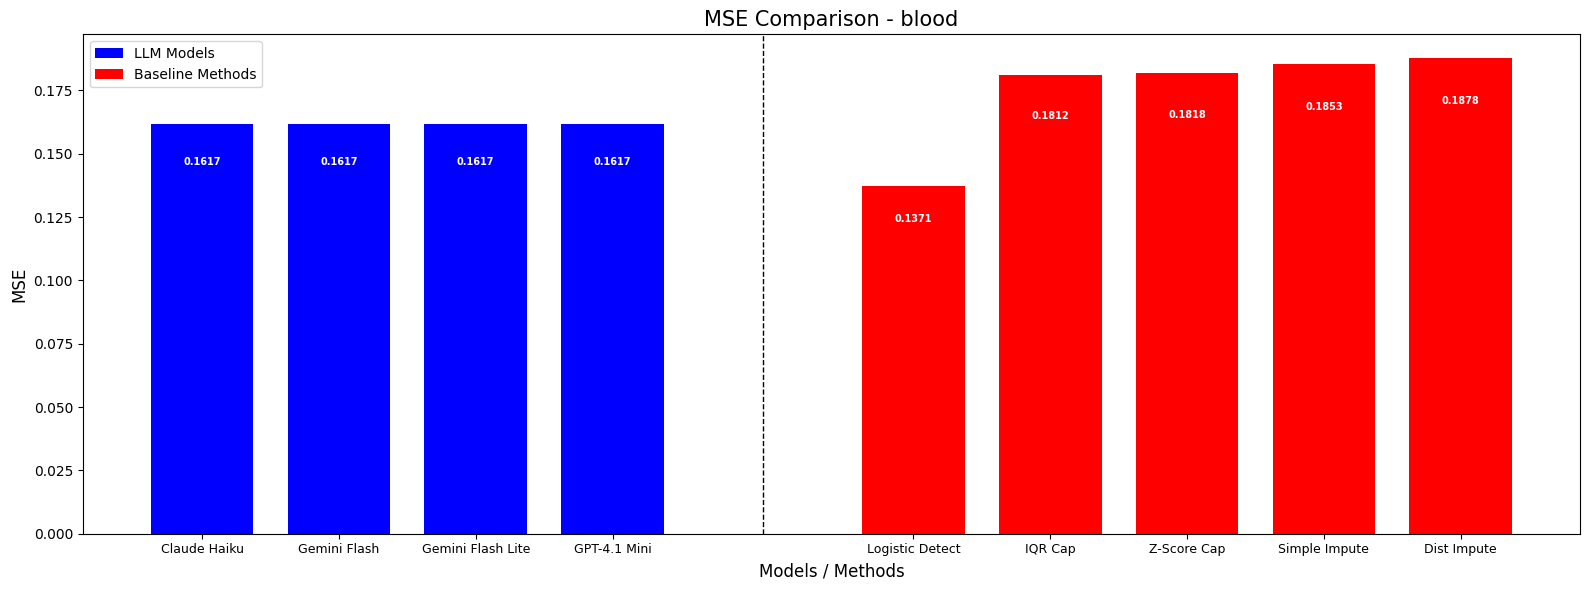

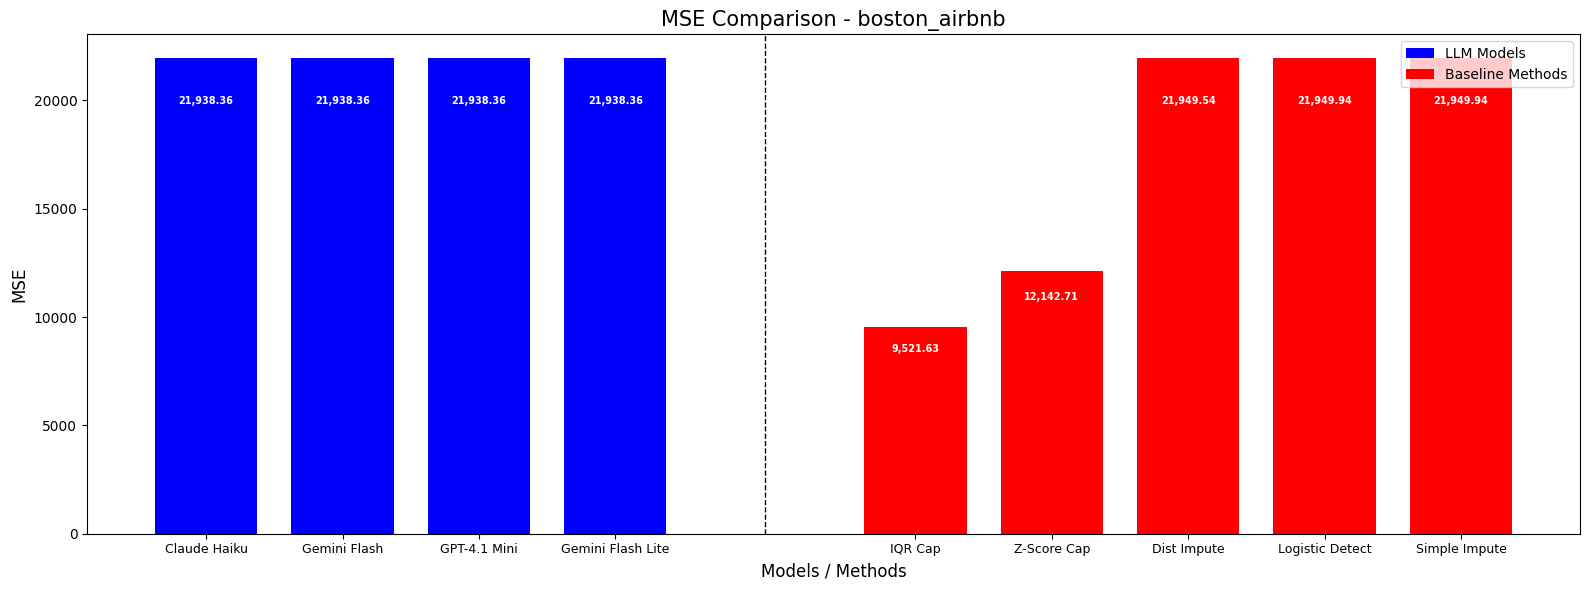

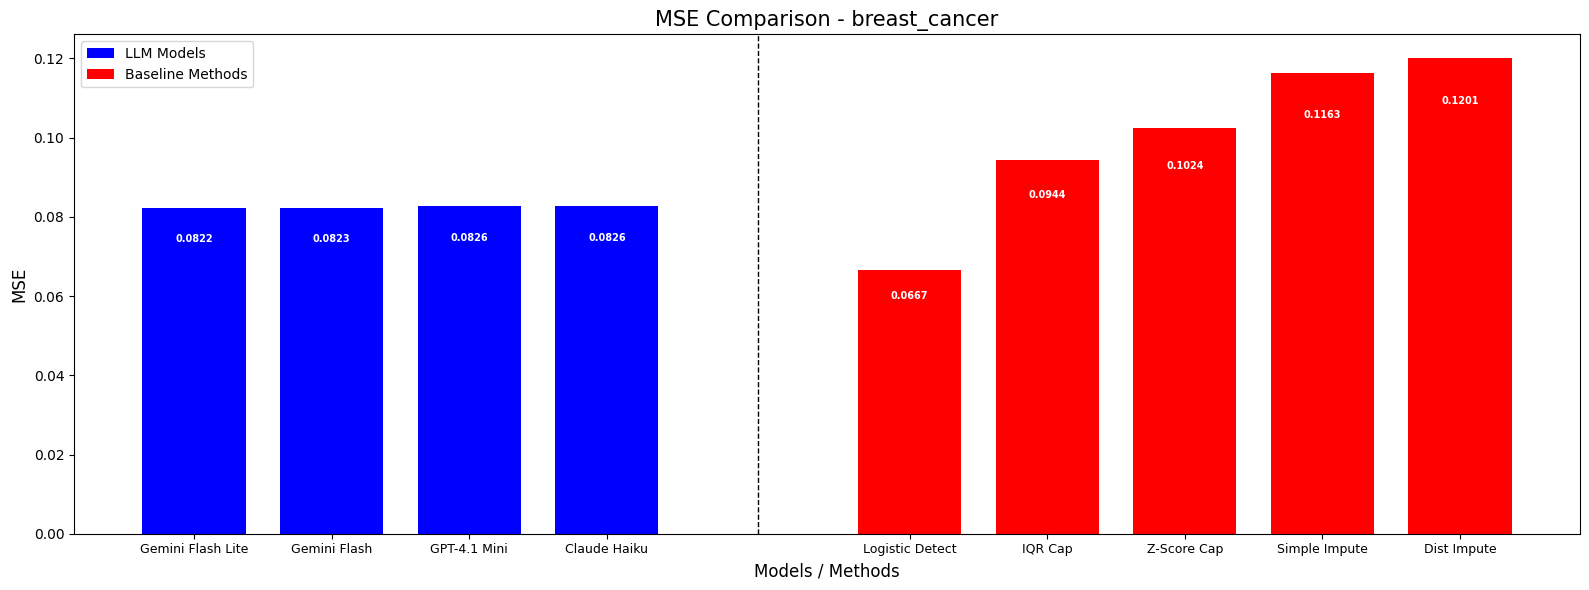

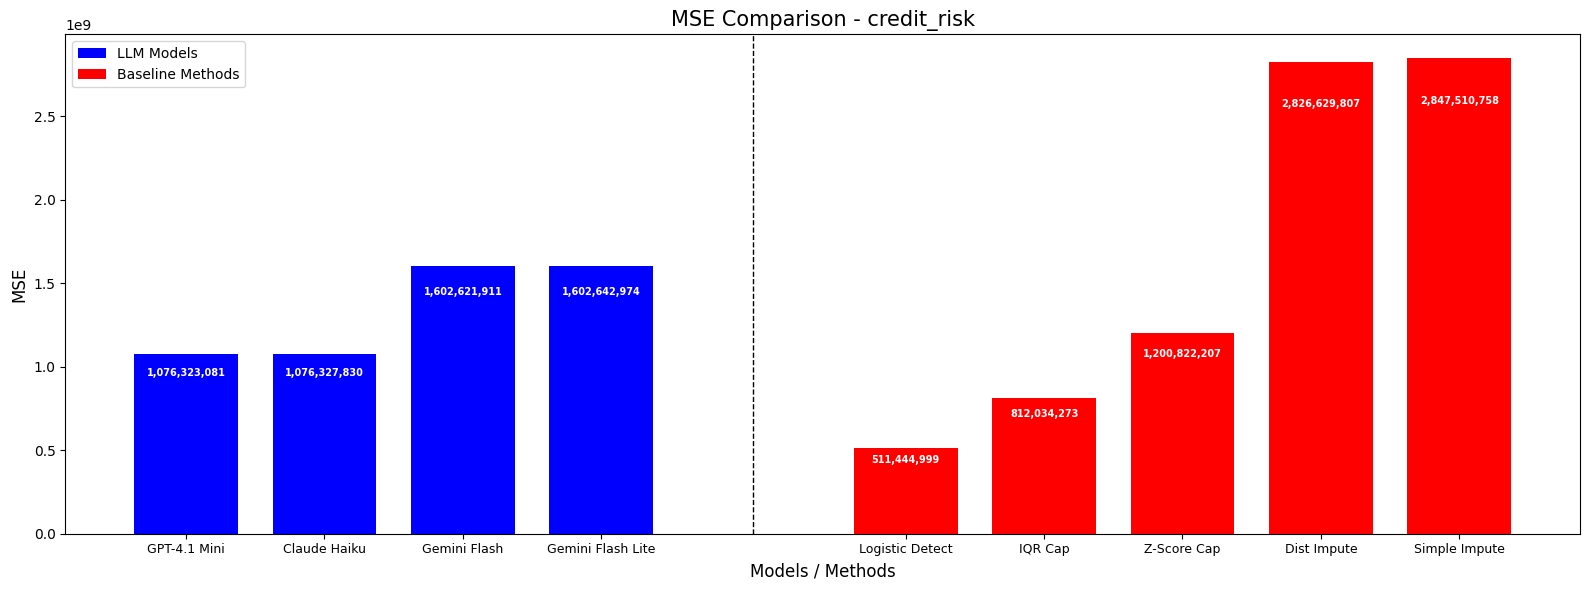

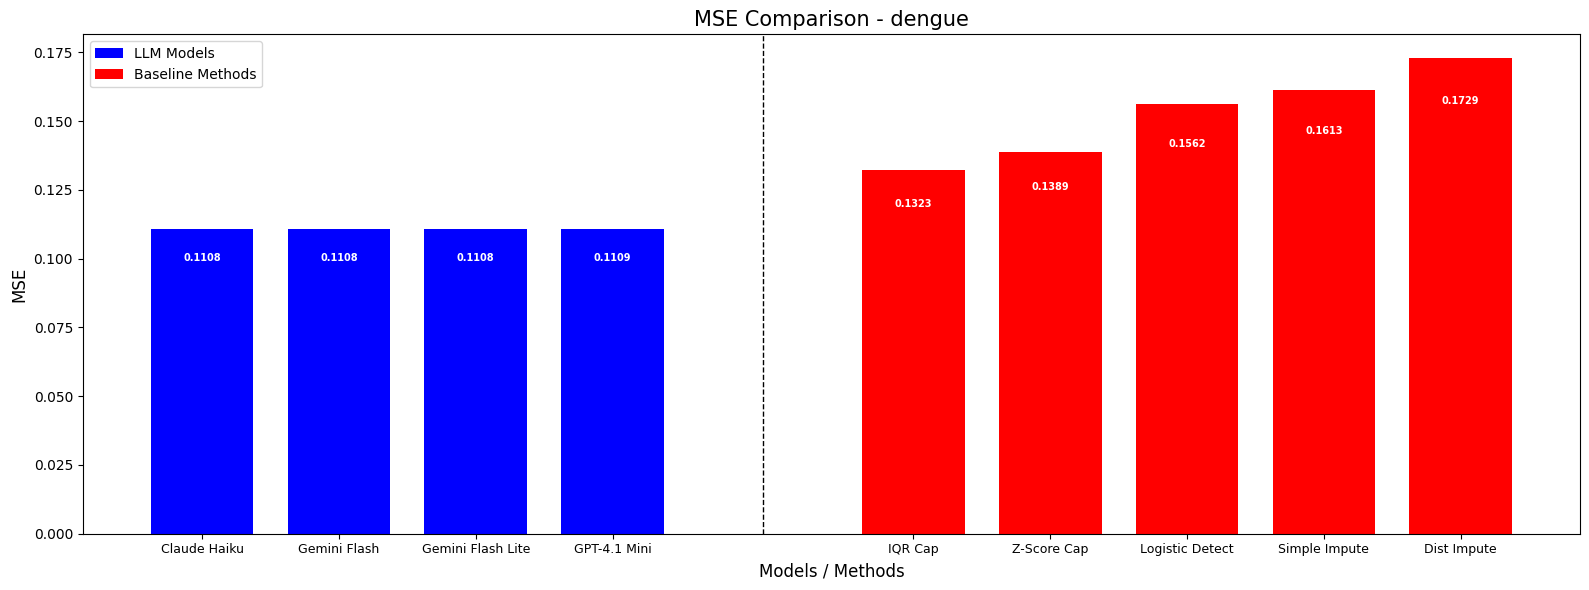

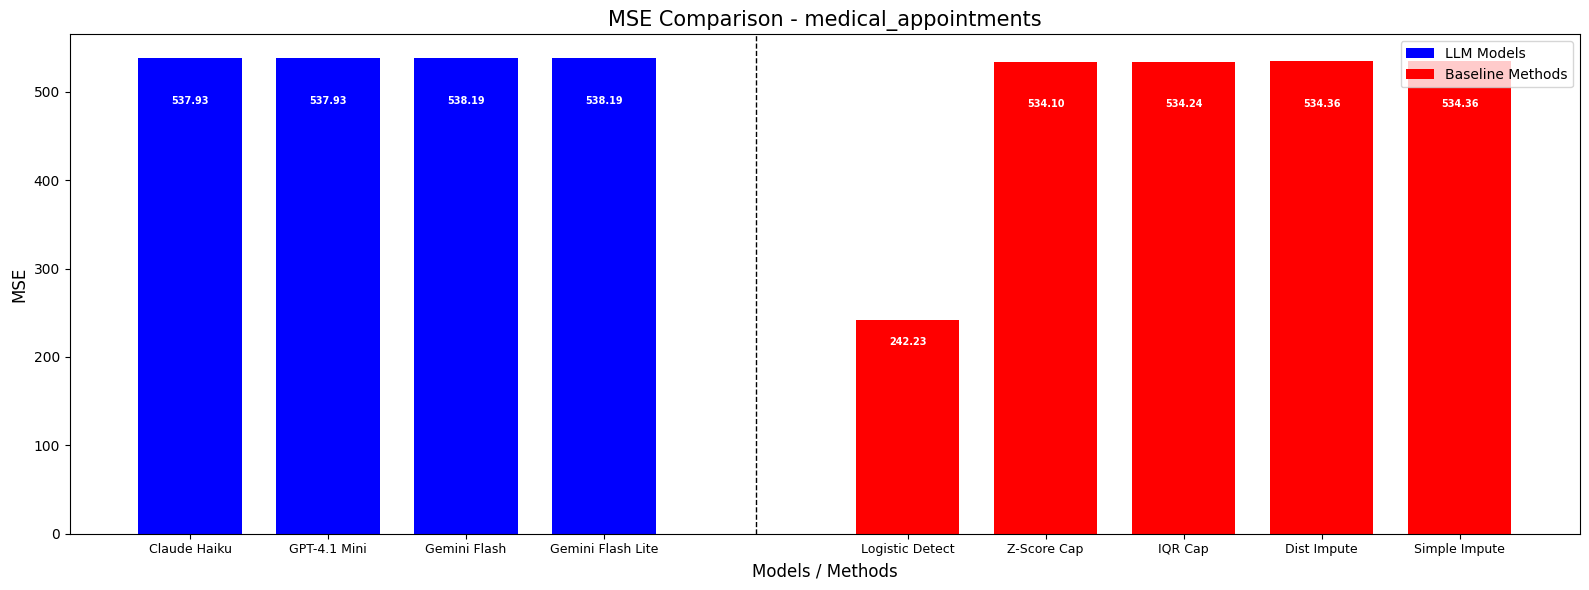

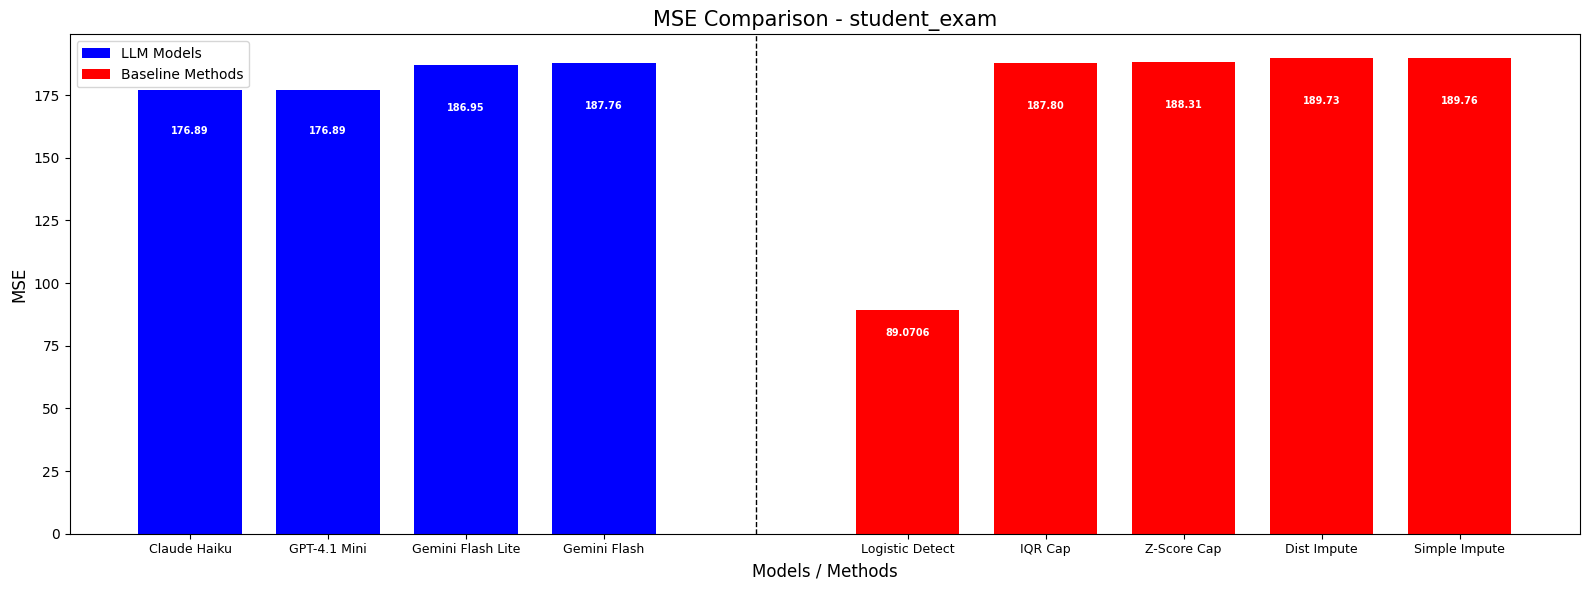

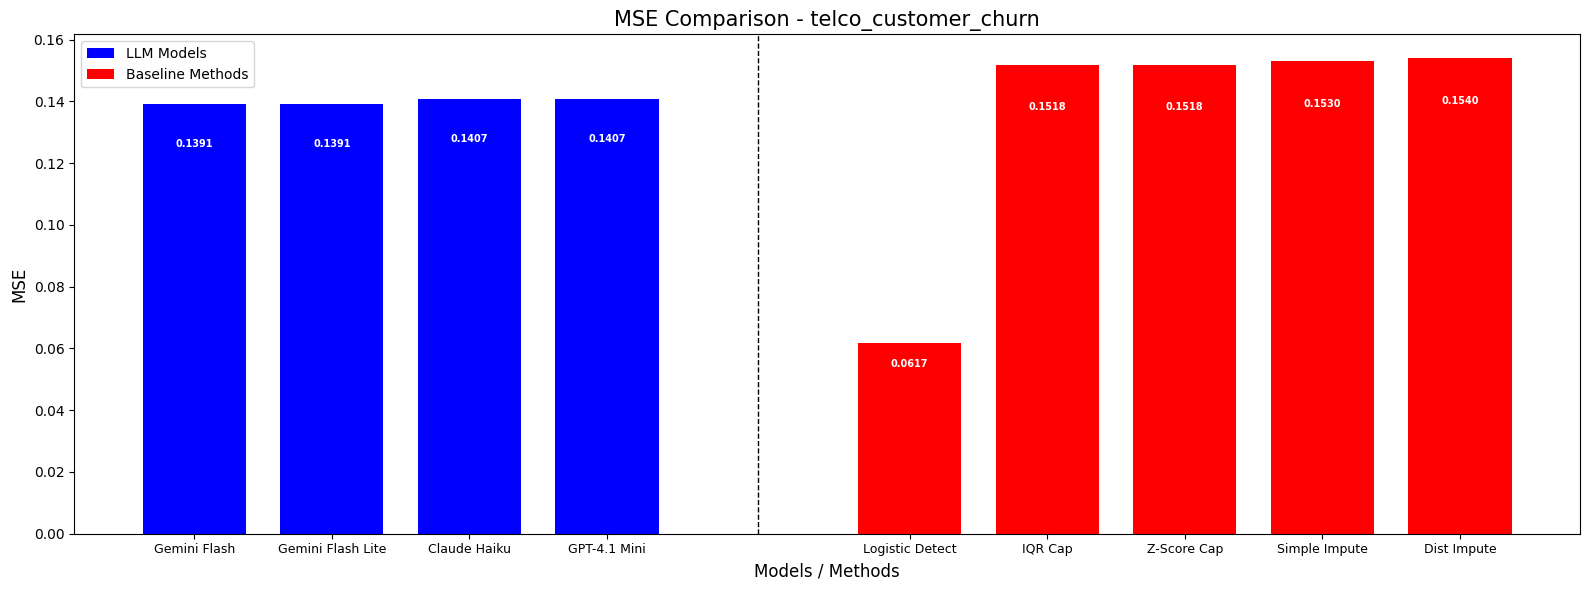

In [98]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

os.makedirs("plots", exist_ok=True)

# ---------------------------
# DEFINE BASELINE METHODS
# ---------------------------
baseline_methods = [
    "simple_impute",
    "dist_impute",
    "iqr_cap",
    "zscore_cap",
    "logistic_detect"
]

# ---------------------------
# SHORT, CLEAN DISPLAY NAMES
# ---------------------------
pretty_names = {
    # Baselines
    "simple_impute": "Simple Impute",
    "dist_impute": "Dist Impute",
    "iqr_cap": "IQR Cap",
    "zscore_cap": "Z-Score Cap",
    "logistic_detect": "Logistic Detect",

    # LLMs
    "claude:claude-3-haiku-20240307": "Claude Haiku",
    "gemini:gemini-2.5-flash": "Gemini Flash",
    "gemini:gemini-2.5-flash-lite": "Gemini Flash Lite",
    "openai:gpt-4o-mini": "GPT-4o Mini",
    "openai:gpt-4.1-mini": "GPT-4.1 Mini"
}

# ---------------------------
# HELPER FOR VALUE LABELS
# ---------------------------
def format_mse(value):
    if value >= 1_000_000:
        return f"{value:,.0f}"
    elif value >= 100:
        return f"{value:,.2f}"
    else:
        return f"{value:.4f}"

# ---------------------------
# PLOT FOR EACH DATASET
# ---------------------------
for dataset in final_combined_table.index:

    row = final_combined_table.loc[dataset].dropna()

    baseline_cols = [col for col in row.index if col in baseline_methods]
    llm_cols = [col for col in row.index if col not in baseline_methods]

    baseline_sorted = row[baseline_cols].sort_values() if baseline_cols else row[[]]
    llm_sorted = row[llm_cols].sort_values() if llm_cols else row[[]]

    plot_row = list(llm_sorted.index) + list(baseline_sorted.index)

    values = row[plot_row].values.astype(float)
    labels = [pretty_names.get(col, col) for col in plot_row]

    colors = ["blue" if col not in baseline_methods else "red" for col in plot_row]

    gap = 1.2
    x_positions = []

    for i in range(len(llm_sorted)):
        x_positions.append(i)

    start_baseline = len(llm_sorted) + gap
    for j in range(len(baseline_sorted)):
        x_positions.append(start_baseline + j)

    # Wider figure so straight labels fit better
    plt.figure(figsize=(16, 6))
    bars = plt.bar(x_positions, values, color=colors, width=0.75)

    plt.title(f"MSE Comparison - {dataset}", fontsize=15)
    plt.xlabel("Models / Methods", fontsize=12)
    plt.ylabel("MSE", fontsize=12)

    # Straight x-axis labels
    plt.xticks(x_positions, labels, rotation=0, ha="center", fontsize=9)

    positive_values = values[values > 0]
    use_log = len(positive_values) > 0 and (positive_values.max() / positive_values.min() > 50)

    if use_log:
        plt.yscale("log")

    if len(llm_sorted) > 0 and len(baseline_sorted) > 0:
        plt.axvline(
            x=len(llm_sorted) - 0.5 + gap / 2,
            color="black",
            linestyle="--",
            linewidth=1
        )

    legend_handles = [
        Patch(facecolor="blue", label="LLM Models"),
        Patch(facecolor="red", label="Baseline Methods")
    ]
    plt.legend(handles=legend_handles)

    ymin, ymax = plt.ylim()

    for bar, value in zip(bars, values):
        x = bar.get_x() + bar.get_width() / 2
        label = format_mse(value)

        if use_log:
            inside_y = value / 1.15
            above_y = value * 1.08

            if inside_y > ymin * 1.5:
                plt.text(
                    x, inside_y, label,
                    ha="center", va="top",
                    fontsize=7, color="white", fontweight="bold"
                )
            else:
                plt.text(
                    x, above_y, label,
                    ha="center", va="bottom",
                    fontsize=7, color="black", fontweight="bold"
                )
        else:
            inside_y = value * 0.92
            above_y = value + (ymax * 0.015)

            if value > ymax * 0.08:
                plt.text(
                    x, inside_y, label,
                    ha="center", va="top",
                    fontsize=7, color="white", fontweight="bold"
                )
            else:
                plt.text(
                    x, above_y, label,
                    ha="center", va="bottom",
                    fontsize=7, color="black", fontweight="bold"
                )

    plt.margins(x=0.05)
    plt.tight_layout()

    safe_dataset_name = str(dataset).replace(" ", "_").lower()
    plt.savefig(f"plots/{safe_dataset_name}_mse_clean.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()